In [1]:
import os
import time
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    top_k_accuracy_score
)

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
BASE_DIR  = 'smartvision_dataset'

TEST_DIR  = f'{BASE_DIR}/classification/test'

In [3]:
IMG_SIZE = (224, 224)

BATCH_SIZE = 32

test_datagen = ImageDataGenerator(
    rescale=1./255
)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 390 images belonging to 26 classes.


In [5]:
vgg16_model = load_model("models/vgg16_final_model.h5")

resnet50_model = load_model("models/resnet50_model.h5")

mobilenet_model = load_model("models/mobilenetv2_final.h5")

efficientnet_model = load_model("models/EfficientNetB0_best.h5")

In [6]:
models_dict = {

    "VGG16": vgg16_model,

    "ResNet50": resnet50_model,

    "MobileNetV2": mobilenet_model,

    "EfficientNetB0": efficientnet_model
}

In [7]:
results = []

y_true = test_gen.classes

class_names = list(test_gen.class_indices.keys())

for name, model in models_dict.items():

    print(f"\nEvaluating {name}...")

    # -------------------------
    # Inference Time
    # -------------------------

    start_time = time.time()

    pred_probs = model.predict(test_gen)

    end_time = time.time()

    inference_time = end_time - start_time

    # -------------------------
    # Predictions
    # -------------------------

    y_pred = np.argmax(pred_probs, axis=1)

    # -------------------------
    # Metrics
    # -------------------------

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        average='weighted'
    )

    recall = recall_score(
        y_true,
        y_pred,
        average='weighted'
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average='weighted'
    )

    # -------------------------
    # Top-5 Accuracy
    # -------------------------

    top5 = top_k_accuracy_score(
        y_true,
        pred_probs,
        k=5
    )

    # -------------------------
    # Model Size
    # -------------------------

    model_paths = {

        "VGG16": "models/vgg16_model.h5",

        "ResNet50": "models/resnet50_model.h5",

        "MobileNetV2": "models/mobilenetv2_model.h5",

        "EfficientNetB0": "models/EfficientNetB0_model.h5"
    }

    size_mb = os.path.getsize(
        model_paths[name]
    ) / (1024 * 1024)

    # -------------------------
    # Save Results
    # -------------------------

    results.append({

        "Model": name,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1-Score": f1,

        "Top-5 Accuracy": top5,

        "Inference Time (s)": inference_time,

        "Model Size (MB)": size_mb
    })

    # -------------------------
    # Classification Report
    # -------------------------

    print("\nClassification Report")

    print(classification_report(
        y_true,
        y_pred,
        target_names=class_names
    ))

    # -------------------------
    # Confusion Matrix
    # -------------------------

    cm = confusion_matrix(y_true, y_pred)


Evaluating VGG16...
13/13 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step


c:\Users\SAKTHI\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


FileNotFoundError: [WinError 2] The system cannot find the file specified: 'models/vgg16_model.h5'

In [50]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1-Score,Top-5 Accuracy,Inference Time (s),Model Size (MB)
2,MobileNetV2,0.392308,0.395855,0.392308,0.373030,0.653846,12.386103,12.801598
0,VGG16,0.058974,0.048578,0.058974,0.022908,0.220513,42.636814,59.365875
1,ResNet50,0.038462,0.001487,0.038462,0.002863,0.210256,28.175502,102.526703
3,EfficientNetB0,0.038462,0.001479,0.038462,0.002849,0.192308,19.308983,19.785805


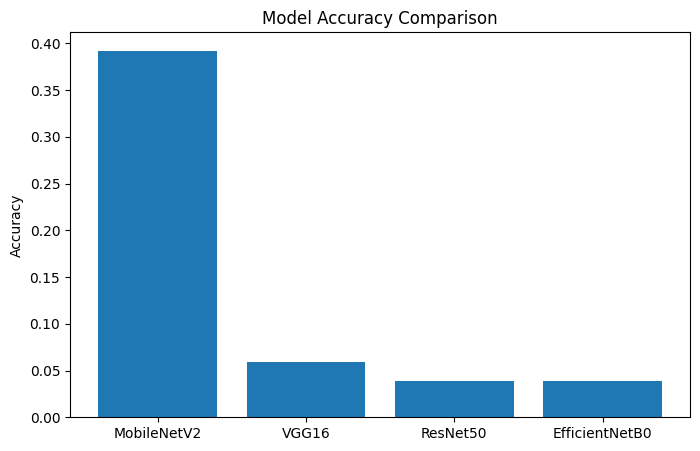

In [51]:
plt.figure(figsize=(8,5))

plt.bar(
    results_df["Model"],
    results_df["Accuracy"]
)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()

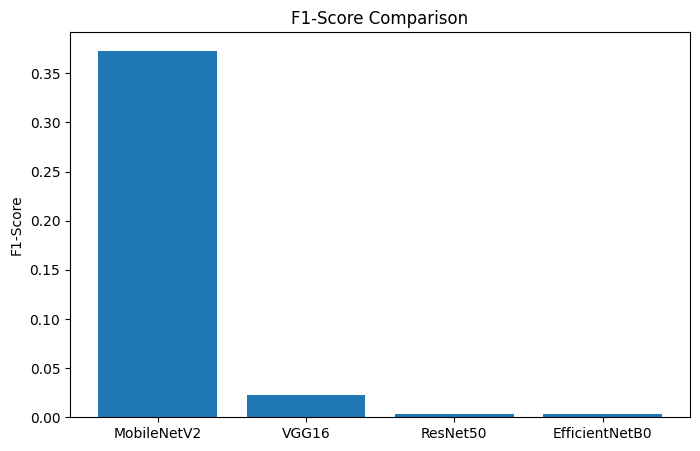

In [52]:
plt.figure(figsize=(8,5))

plt.bar(
    results_df["Model"],
    results_df["F1-Score"]
)

plt.title("F1-Score Comparison")

plt.ylabel("F1-Score")

plt.show()

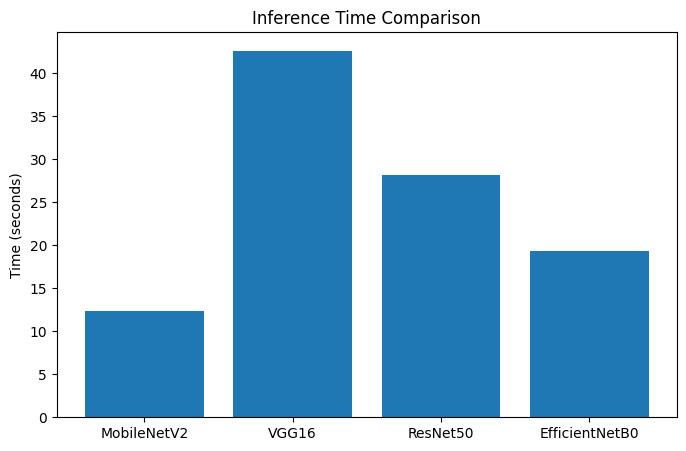

In [53]:
plt.figure(figsize=(8,5))

plt.bar(
    results_df["Model"],
    results_df["Inference Time (s)"]
)

plt.title("Inference Time Comparison")

plt.ylabel("Time (seconds)")

plt.show()

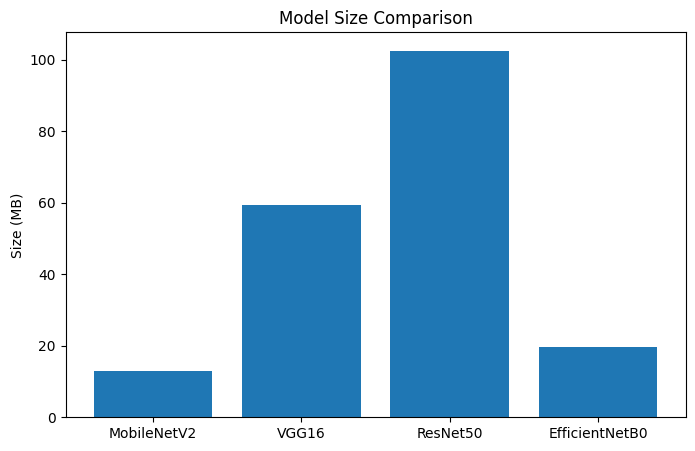

In [54]:
plt.figure(figsize=(8,5))

plt.bar(
    results_df["Model"],
    results_df["Model Size (MB)"]
)

plt.title("Model Size Comparison")

plt.ylabel("Size (MB)")

plt.show()

In [62]:
best_model = results_df.iloc[0]

print("Best Model Selected")

print(best_model)

Best Model Selected
Model                 MobileNetV2
Accuracy                 0.392308
Precision                0.395855
Recall                   0.392308
F1-Score                  0.37303
Top-5 Accuracy           0.653846
Inference Time (s)      12.386103
Model Size (MB)         12.801598
Name: 2, dtype: object
